In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Dataset\FIFA PLAYER SKOR.csv')
df.head(5)

<>:1: SyntaxWarning: invalid escape sequence '\F'
<>:1: SyntaxWarning: invalid escape sequence '\F'
C:\Users\HP\AppData\Local\Temp\ipykernel_21840\1404250217.py:1: SyntaxWarning: invalid escape sequence '\F'
  df = pd.read_csv('Dataset\FIFA PLAYER SKOR.csv')


,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


In [3]:
df.isnull().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

In [4]:
df.isna().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


In [6]:
df.head(5)

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


### 1. Analisis Pemain & PosisiRata-rata Rating vs Harga: 
1. Posisi mana yang memiliki rata-rata Overall_Rating tertinggi, dan apakah posisi tersebut juga memiliki rata-rata Value Per M$ tertinggi?
2. Siapakah pemain "undervalued" (pemain dengan Overall_Rating tinggi namun memiliki Value Per M$ di atas rata-rata)?
3. Berapa selisih antara Overall_Rating saat ini dengan Future Potential berdasarkan posisi pemain?

### 2. Analisis Umur & PotensiUsia Emas: 
1. Pada rentang usia (Age) berapakah pemain biasanya mencapai puncak Overall_Rating mereka?
2. Apakah ada korelasi yang kuat antara Future Potential seorang pemain muda dengan Value Per M$ mereka saat ini?
3. Siapakah 5 pemain muda (di bawah 21 tahun) yang memiliki selisih terbesar antara Overall_Rating dan Future Potential?

### 3. Analisis Negara & TimDominasi Negara:
1. Negara (Country) mana yang menyumbangkan pemain paling banyak dengan Overall_Rating di atas 85?
2. Tim (Team) manakah yang memiliki skuad paling efisien (rata-rata Total_Stats Score tinggi namun total Value Per M$ rendah)?
3. Distribusi Statistik: Bagaimana distribusi Total_Stats Score pemain jika dibandingkan antar negara?

### 4. Analisis Nilai EkonomiPenentu Harga:
1. Faktor manakah yang memiliki korelasi lebih kuat terhadap nilai pasar pemain,performa saat ini (Overall Rating) ataukah prospek masa depan (Future Potential)?"
2. Apakah pemain dengan Total_Stats Score yang tinggi selalu memiliki harga jual (Value Per M$) yang tinggi pula?
3. Jika kita mengelompokkan pemain berdasarkan Age, bagaimana tren penurunan Value Per M$ seiring bertambahnya usia pemain?

### 5. Analisis StatistikOutlier Performa: 
1. Siapakah pemain yang memiliki Total_Stats Score tertinggi namun tidak bermain di Team besar?
2. Bagaimana perbandingan rata-rata Total_Stats Score untuk pemain dengan posisi Goalkeeper dibandingkan dengan posisi Midfielder?

In [7]:
df.head(5)

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


### 1. Analisis Pemain & PosisiRata-rata Rating vs Harga: 
1. Posisi mana yang memiliki rata-rata Overall_Rating tertinggi, dan apakah posisi tersebut juga memiliki rata-rata Value Per M$ tertinggi?
2. Siapakah pemain "undervalued" (pemain dengan Overall_Rating tinggi namun memiliki Value Per M$ di bawah rata-rata)?
3. Berapa selisih antara Overall_Rating saat ini dengan Future Potential berdasarkan posisi pemain?

In [8]:
# soal nomor 1
meanRating = df['Overall_Rating'].mean().round(2)
meanValue = df['Value Per M$'].mean().round(2)

Value = df.loc[((df['Overall_Rating'] > meanRating) & (df['Value Per M$']>meanValue)),['Position','Value Per M$','Overall_Rating']]
positionValue = Value.sort_values(by=['Value Per M$','Overall_Rating'], ascending=False)

hasil = positionValue['Position'].iloc[0] if not positionValue.empty else "Pemain tidak ditemukan"
print(f"Posisi tersebut adalah: {hasil}")

positionValue

Posisi tersebut adalah: LW


,Position,Value Per M$,Overall_Rating
103,LW,190.5,91
67,ST,176.5,90
110,LW,109.0,86
370,CAM,107.5,91
214,CB,107.5,88
...,...,...,...
810,LW,2.6,67
824,RM,2.6,67
933,CAM,2.6,67
1123,CDM,2.6,67


C:\Users\HP\AppData\Local\Temp\ipykernel_21840\3801894583.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='Position', y='Value Per M$', palette=colors)


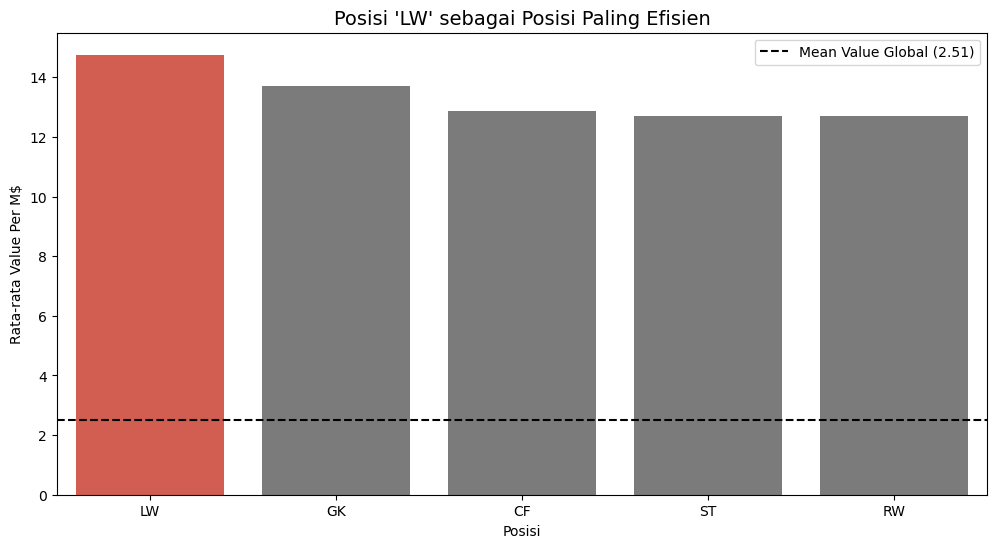

Data tidak ditemukan untuk divisualisasikan.


In [9]:
df_plot = Value.groupby('Position').mean().reset_index()
df_plot = df_plot.sort_values('Value Per M$', ascending=False).head(5)
target_pos = hasil 
colors = ['#e74c3c' if (x == target_pos) else "#7b7b7b" for x in df_plot['Position']]
    
plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='Position', y='Value Per M$', palette=colors)
plt.axhline(meanValue, color='black', linestyle='--', label=f'Mean Value Global ({meanValue})')
plt.title(f"Posisi '{target_pos}' sebagai Posisi Paling Efisien", fontsize=14)
plt.xlabel('Posisi')
plt.ylabel('Rata-rata Value Per M$')
plt.legend()
plt.show()
print("Data tidak ditemukan untuk divisualisasikan.")

In [10]:
# soal nomor 2
topRating= df['Overall_Rating'].max()
meanValue = df['Value Per M$'].mean()
pemain = df.loc[((df['Overall_Rating'] == topRating) & (df['Value Per M$'] > meanValue)), ['Name','Team','Overall_Rating','Value Per M$']]
pemain_termahal = pemain.sort_values(by='Value Per M$', ascending=False)

hasil = pemain_termahal['Name'].iloc[0] if not pemain_termahal.empty else "Pemain yang dimaksud tidak ada"
print(f"Pemain tersebut adalah: {hasil}")



Pemain tersebut adalah: Kylian Mbappé


C:\Users\HP\AppData\Local\Temp\ipykernel_21840\3511409337.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_team, x='Name', y='Overall_Rating', palette=colors)


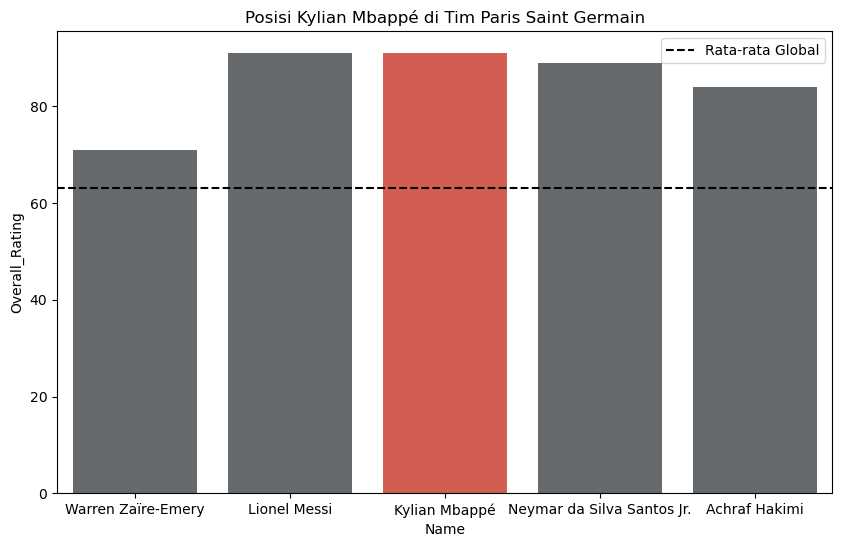

In [11]:
target_player = pemain_termahal.iloc[0]['Name']
target_team = pemain_termahal.iloc[0]['Team']
df_team = df[df['Team'] == target_team].head(5)
colors = ['#e74c3c' if (x == target_player) else "#656a6d" for x in df_team['Name']]

plt.figure(figsize=(10, 6))
sns.barplot(data=df_team, x='Name', y='Overall_Rating', palette=colors)
plt.axhline(df['Overall_Rating'].mean(), color='black', linestyle='--', label='Rata-rata Global')
plt.title(f"Posisi {target_player} di Tim {target_team}")
plt.legend()
plt.show()

In [12]:
#soal nomor 3
df['Gap_potential']= df['Overall_Rating'] - df['Future Potential']
gapPerposition = df.groupby('Position')[['Gap_potential']].mean().sort_values(by='Gap_potential',ascending=True)
gapPerposition.head(5)

,Gap_potential
Position,
CAM,-8.123749
CM,-8.017950
GK,-8.004237
RW,-7.667610
LW,-7.429439


C:\Users\HP\AppData\Local\Temp\ipykernel_21840\3993757642.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot,  x='Gap_potential', y='Position', palette= colors )
C:\Users\HP\AppData\Local\Temp\ipykernel_21840\3993757642.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


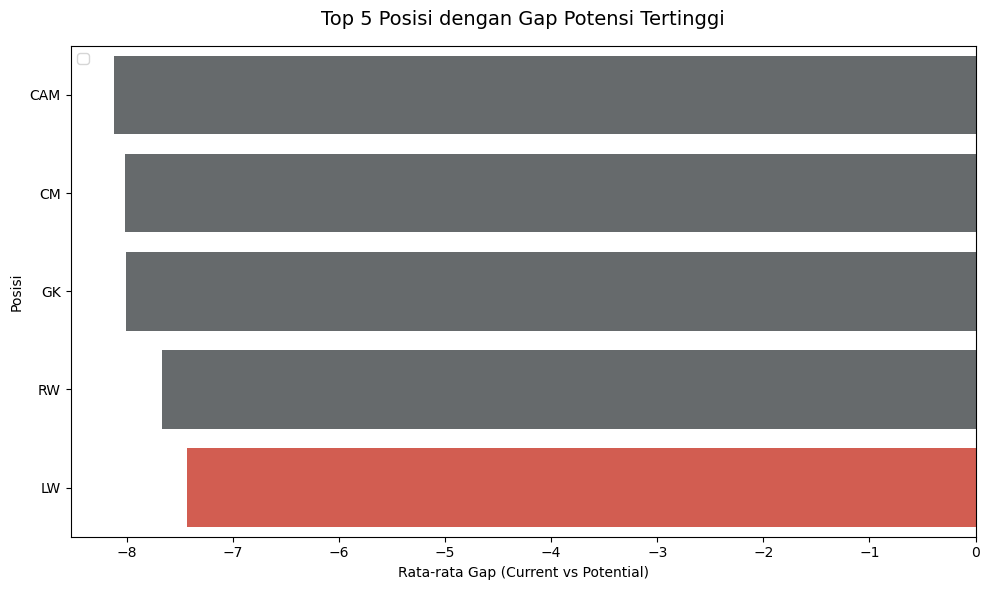

In [13]:
df_plot = gapPerposition.head(5).reset_index()
max_gap = df_plot['Gap_potential'].max()
colors = ['#e74c3c' if (x == max_gap) else "#656a6d" for x in df_plot['Gap_potential']]

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot,  x='Gap_potential', y='Position', palette= colors )
plt.title('Top 5 Posisi dengan Gap Potensi Tertinggi', fontsize=14, pad=15)
plt.xlabel('Rata-rata Gap (Current vs Potential)')
plt.ylabel('Posisi')
plt.tight_layout()
plt.legend()
plt.show()

### 2. Analisis Umur & PotensiUsia Emas: 
1. Pada rentang usia (Age) berapakah pemain biasanya mencapai puncak Overall_Rating mereka?
2. Apakah ada korelasi yang kuat antara Future Potential seorang pemain muda dengan Value Per M$ mereka saat ini?
3. Siapakah 5 pemain muda (di bawah 21 tahun) yang memiliki selisih terbesar antara Overall_Rating dan Future Potential?

In [14]:
df.head(5)

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score,Gap_potential
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660,0
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620,0
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480,-2
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695,0
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640,0


In [15]:
# soal nomor 1
data = df[['Age','Overall_Rating']]
meanRating = df['Overall_Rating'].mean().round(2)
age_stats = data.groupby('Age')['Overall_Rating'].mean().reset_index()
productive_range = age_stats[age_stats['Overall_Rating'] > meanRating].round(2)

batasAwal = productive_range.index[0]
batasAkhir = productive_range.index[-2]

print(f"Pemain mendapatkan puncal Overall pada rentang usia {productive_range['Age'].iloc[0]} hingga usia {productive_range['Age'].iloc[-2]}")



Pemain mendapatkan puncal Overall pada rentang usia 22 hingga usia 42


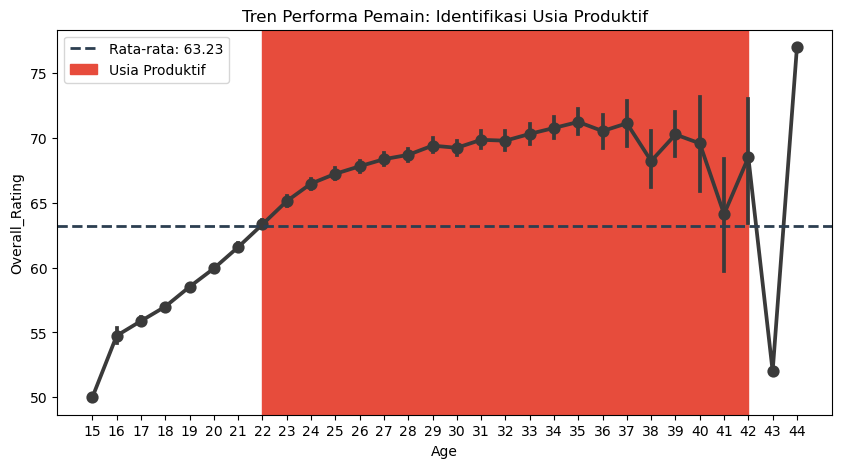

In [16]:
plt.figure(figsize=(10, 5))
sns.pointplot(data=data,x='Age',y='Overall_Rating',color= "#3a3a3a")
plt.axhline(meanRating, color='#2c3e50', linestyle='--', linewidth=2, label=f'Rata-rata: {meanRating:.2f}')
plt.axvspan(xmin=batasAwal, xmax=batasAkhir, color='#e74c3c', label='Usia Produktif')
plt.title('Tren Performa Pemain: Identifikasi Usia Produktif')
plt.legend()
plt.show()

Kesimpulan: Korelasi fitur 'Future Potentual' dan 'Value Per M$' sangat rendah di angka: 0.5 


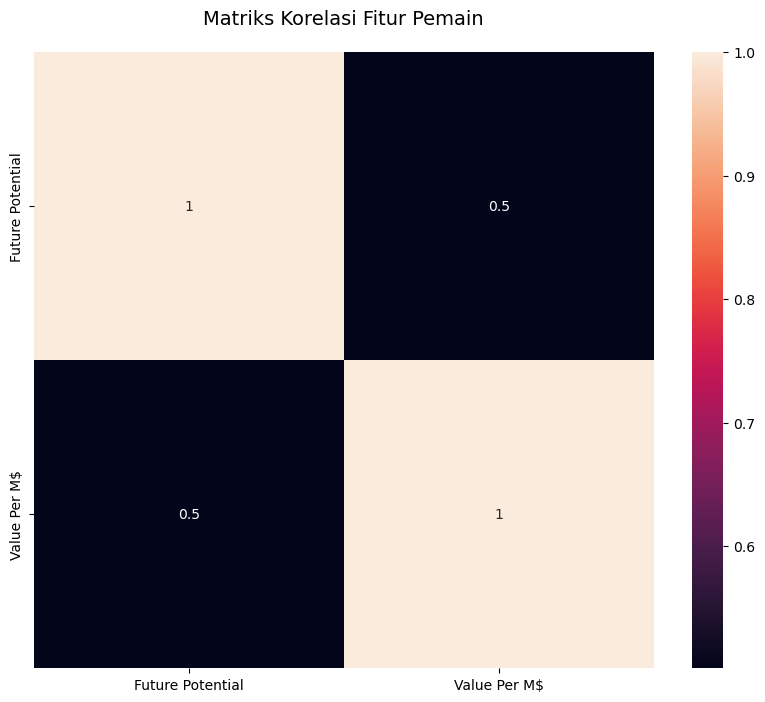

In [17]:
# soal nomor 2
col_matrix = df[['Future Potential', 'Value Per M$']].corr()
print(f"Kesimpulan: Korelasi fitur 'Future Potentual' dan 'Value Per M$' sangat rendah di angka: {col_matrix.iloc[0,1].round(2)} ")

plt.figure(figsize=(10,8))
sns.heatmap(col_matrix,annot=True)
plt.title('Matriks Korelasi Fitur Pemain',fontsize=14, pad=20)
plt.show()

In [18]:
#soal nomor 3
under_21 = df[df['Age']<21]
df_plot = under_21[['Name','Gap_potential']].sort_values(by='Gap_potential',ascending=True).head(10)
max_gap = df['Gap_potential'].min()
colors = ['#e74c3c' if (x == max_gap) else "#656a6d" for x in df_plot['Gap_potential']]

print("Pemain usia dibawah 21 tahun dengan Gap Potential terbanyak:")

df_plot

Pemain usia dibawah 21 tahun dengan Gap Potential terbanyak:


,Name,Gap_potential
15527,Kerr Smith,-26
2454,Dylan Lobban,-26
2432,De Pievre Ilunga,-26
1427,Emre Tezgel,-26
9983,Yoni Gomis,-26
13562,Aidan Denholm,-25
8742,Nathan Lowe,-25
11333,Daniel Gore,-25
2478,Archie Gray,-24
15000,Felipe Valencia,-24


C:\Users\HP\AppData\Local\Temp\ipykernel_21840\3506767963.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot,  x='Gap_potential', y='Name', palette= colors )
C:\Users\HP\AppData\Local\Temp\ipykernel_21840\3506767963.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


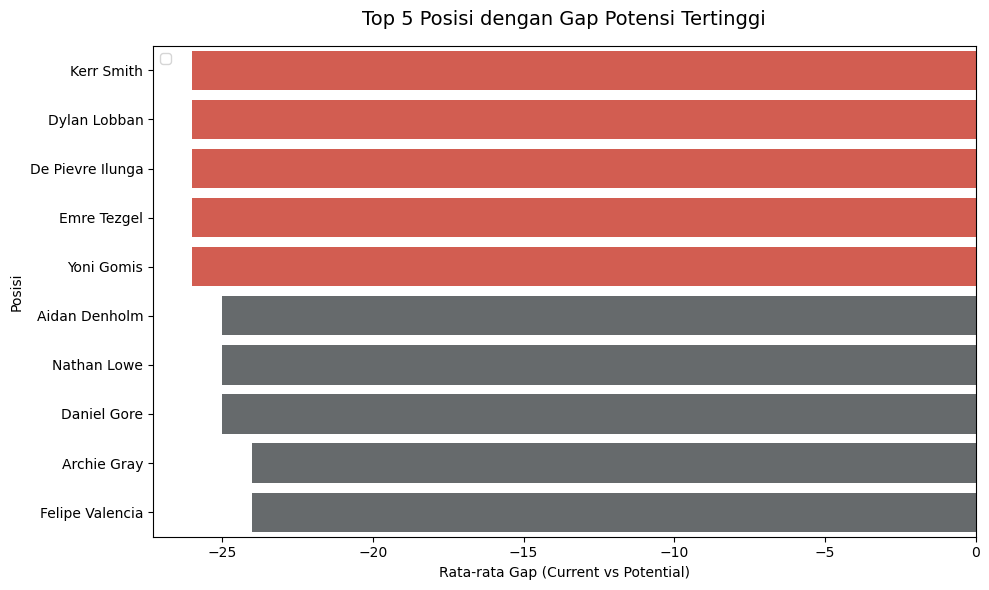

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot,  x='Gap_potential', y='Name', palette= colors )
plt.title('Top 5 Posisi dengan Gap Potensi Tertinggi', fontsize=14, pad=15)
plt.xlabel('Rata-rata Gap (Current vs Potential)')
plt.ylabel('Posisi')
plt.tight_layout()
plt.legend()
plt.show()

### 3. Analisis Negara & TimDominasi Negara:
1. Negara (Country) mana yang menyumbangkan pemain paling banyak dengan Overall_Rating di atas 85?
2. Tim (Team) manakah yang memiliki skuad paling efisien (rata-rata Total_Stats Score tinggi namun total Value Per M$ rendah)?
3. Bagaimana distribusi Total_Stats Score pemain jika dibandingkan antar negara?

In [20]:
df.head(5)

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score,Gap_potential
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660,0
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620,0
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480,-2
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695,0
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640,0


In [21]:
# nomor 1
countryPlayer = df.groupby('Country')['Name'].count().reset_index()
countryPlayer.columns = ['Country','Total_Player']
country_top85 = countryPlayer[countryPlayer['Total_Player'] > 85].sort_values(by='Total_Player' ,ascending=False).head(10)
country = country_top85['Total_Player'].max()
colors = ['#e74c3c' if (x == country) else "#656a6d" for x in country_top85['Total_Player']]
print(f'Negara paling banyak pemain bola adalah: {country_top85.iloc[0].Country} sebanyak {country_top85.iloc[0].Total_Player} pemain')


Negara paling banyak pemain bola adalah: England sebanyak 1549 pemain


C:\Users\HP\AppData\Local\Temp\ipykernel_21840\2237064529.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_top85, x='Country', y='Total_Player', palette=colors)


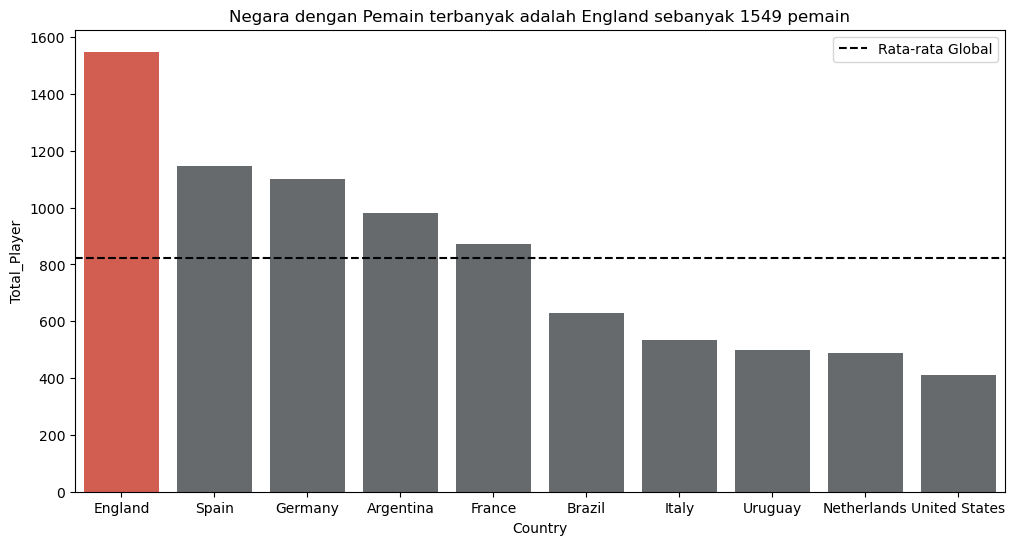

In [22]:
plt.figure(figsize=(12, 6))
sns.barplot(data=country_top85, x='Country', y='Total_Player', palette=colors)
plt.axhline(country_top85['Total_Player'].mean(), color='black', linestyle='--', label='Rata-rata Global')
plt.title(f"Negara dengan Pemain terbanyak adalah {country_top85.iloc[0].Country} sebanyak {country_top85.iloc[0].Total_Player} pemain")
plt.legend()
plt.show()

In [23]:
#Soal Nomor 2
stats_per_team = df.groupby('Team').agg({'Total_Stats Score': 'mean','Value Per M$': 'sum'})
stats_per_team = stats_per_team[stats_per_team['Value Per M$'] > 0]
stats_per_team['Efficiency'] = (stats_per_team['Total_Stats Score'] / stats_per_team['Value Per M$']).round(2)
tim_paling_efisien = stats_per_team.sort_values('Efficiency', ascending=False).head(5)

team = tim_paling_efisien.index[0]
colors = ['#e74c3c' if (x == team) else "#656a6d" for x in tim_paling_efisien.index]
print(f"Club bola yang memiliki efisien paling tinggi: {tim_paling_efisien.index[0]}")

tim_paling_efisien



Club bola yang memiliki efisien paling tinggi: Volga


,Total_Stats Score,Value Per M$,Efficiency
Team,,,
Volga,1265.0,0.001,1265000.00
Aldershot Town,1109.0,0.035,31685.71
Red Star,1049.0,0.035,29971.43
Limerick,1564.0,0.060,26066.67
Notts County,1716.0,0.080,21450.00


C:\Users\HP\AppData\Local\Temp\ipykernel_21840\1108888303.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tim_paling_efisien, y='Team', x='Efficiency', palette=colors)


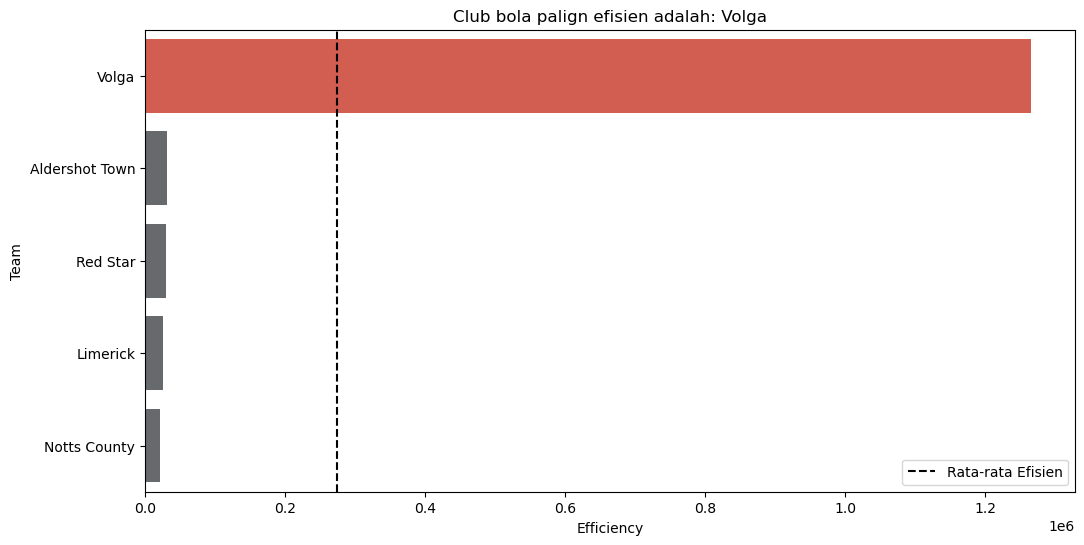

In [24]:
plt.figure(figsize=(12, 6))
sns.barplot(data=tim_paling_efisien, y='Team', x='Efficiency', palette=colors)
plt.axvline(tim_paling_efisien['Efficiency'].mean(), color='black', linestyle='--', label='Rata-rata Efisien')
plt.title(f"Club bola palign efisien adalah: {tim_paling_efisien.index[0]}")
plt.legend()
plt.show()

In [25]:
#Soal nomor 3
scoreCountry = df.groupby('Country')[['Total_Stats Score']].sum().sort_values(by='Total_Stats Score',ascending=False).head(5).index
country = scoreCountry[0]
colors = ['#e74c3c' if (x == country) else "#656a6d" for x in scoreCountry]


C:\Users\HP\AppData\Local\Temp\ipykernel_21840\3695824874.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Country', y='Total_Stats Score', order=scoreCountry,palette=colors)


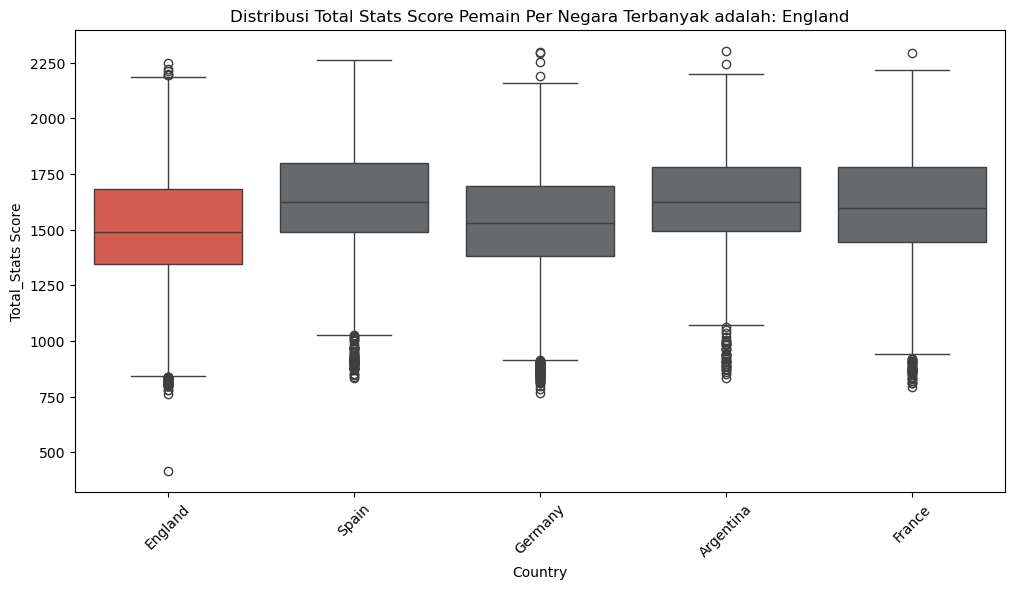

In [26]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Country', y='Total_Stats Score', order=scoreCountry,palette=colors)
plt.title(f'Distribusi Total Stats Score Pemain Per Negara Terbanyak adalah: {scoreCountry[0]}')
plt.xticks(rotation=45)
plt.show()

### 4. Analisis Nilai EkonomiPenentu Harga:
1. Faktor manakah yang memiliki korelasi lebih kuat terhadap nilai pasar pemain,performa saat ini (Overall Rating) ataukah prospek masa depan (Future Potential)?"
2. Apakah pemain dengan Total_Stats Score yang tinggi selalu memiliki harga jual (Value Per M$) yang tinggi pula?
3. Jika kita mengelompokkan pemain berdasarkan Age, bagaimana tren penurunan Value Per M$ seiring bertambahnya usia pemain?

In [27]:
df.head(5)

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score,Gap_potential
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660,0
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620,0
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480,-2
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695,0
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640,0


In [28]:
# soal nomor 1
col_Value = df[['Future Potential','Overall_Rating','Value Per M$']].corr()
target_cor = col_Value['Value Per M$'].drop('Value Per M$')
fitur_terkuat = target_cor.idxmax()
nilai_fitur = target_cor.max()

print(f"Fitur yang paling berpengaruh terhadap harga adalah: {fitur_terkuat}")
print(f"Dengan nilai korelasi sebesar: {nilai_fitur:.2f}")

Fitur yang paling berpengaruh terhadap harga adalah: Overall_Rating
Dengan nilai korelasi sebesar: 0.56


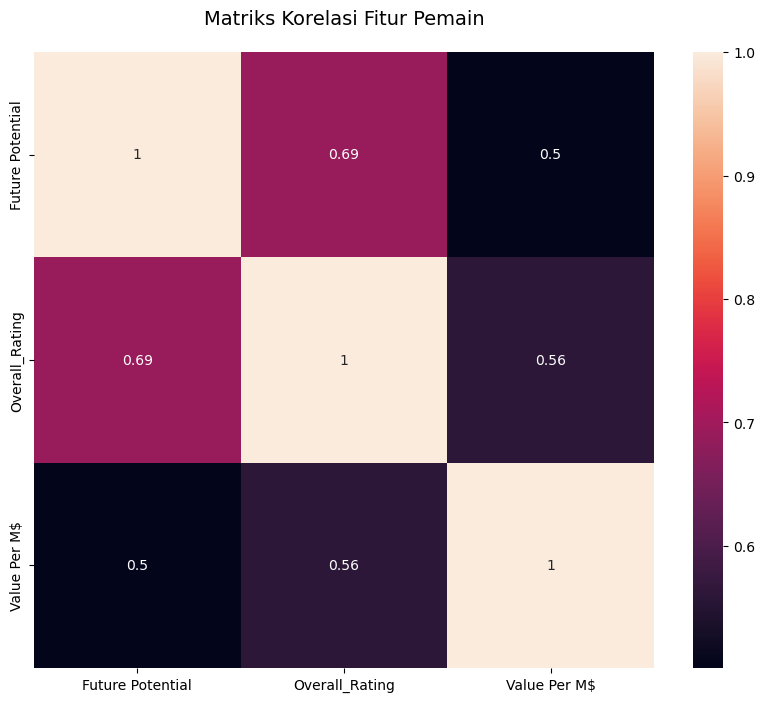

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(col_Value,annot=True)
plt.title('Matriks Korelasi Fitur Pemain',fontsize=14, pad=20)
plt.show()

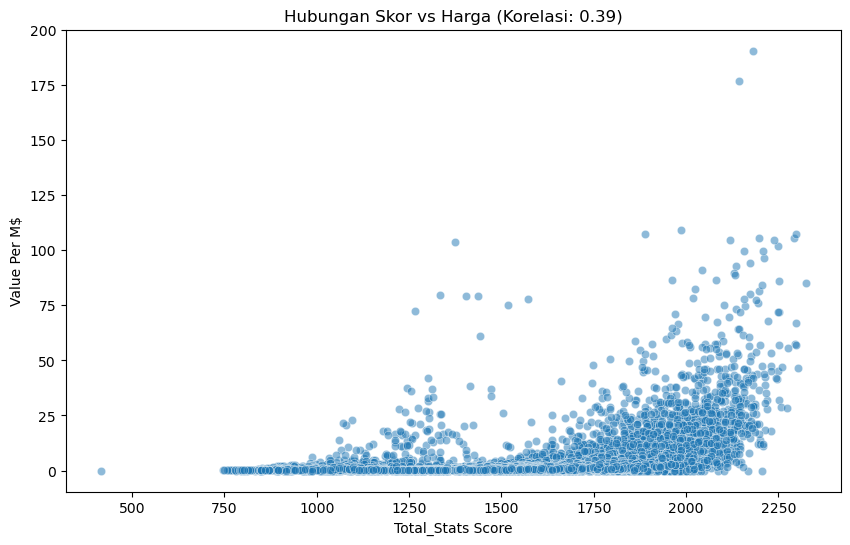

Nilai Korelasi: 0.39
Kesimpulan: Tidak selalu. Ada pemain dengan skor tinggi tapi harga tetap rendah.


In [30]:
#Soal Nomor 2
korelasi = df['Total_Stats Score'].corr(df['Value Per M$'])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Total_Stats Score', y='Value Per M$', alpha=0.5)
plt.title(f'Hubungan Skor vs Harga (Korelasi: {korelasi:.2f})')
plt.show()

print(f"Nilai Korelasi: {korelasi:.2f}")
if korelasi > 0.7: #Angka 0.7 digunakan sebagai standar karena dalam statistika, nilai tersebut dianggap sebagai batas ambang hubungan yang kuat
    print("Kesimpulan: Ya, pemain jago cenderung selalu mahal.")
else:
    print("Kesimpulan: Tidak selalu. Ada pemain dengan skor tinggi tapi harga tetap rendah.")


In [31]:
# Soal nomor 3
# 3. Jika kita mengelompokkan pemain berdasarkan Age, bagaimana tren penurunan Value Per M$ seiring bertambahnya usia pemain?
age_player = df.groupby('Age')['Value Per M$'].mean()
mean_value = df['Value Per M$'].mean().round(2)
max_val = age_player.values.max()
max_age = age_player.idxmax()

print(f"player mulai mengalami penuruan Value Per M$ pada usia: {max_age:.2f}")

player mulai mengalami penuruan Value Per M$ pada usia: 30.00


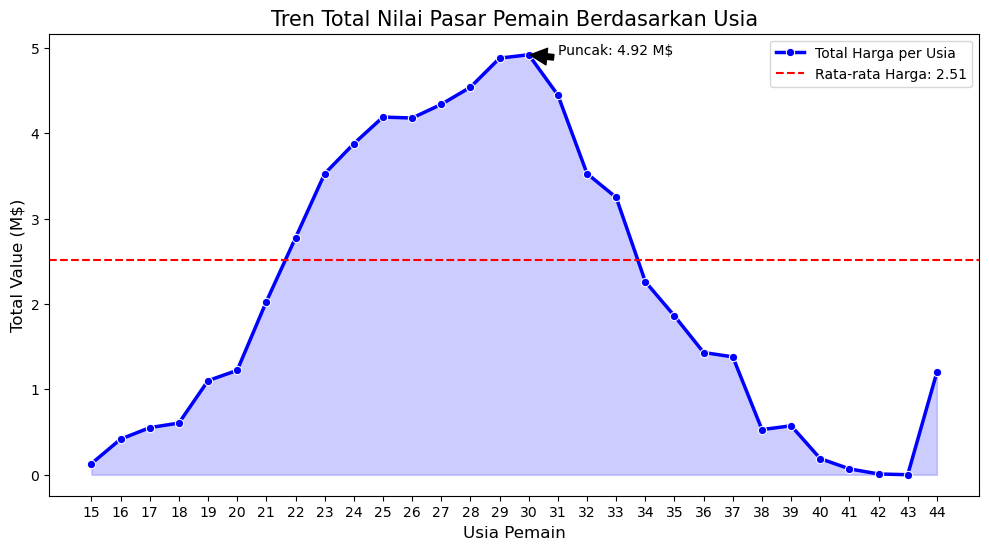

In [32]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=age_player.index, y=age_player.values, marker='o', color='b', linewidth=2.5, label='Total Harga per Usia')
# 4. Tambahkan area di bawah garis agar lebih estetik (Area Chart)
plt.fill_between(age_player.index, age_player.values, alpha=0.2, color='b')
plt.axhline(mean_value, color='red', linestyle='--', label=f'Rata-rata Harga: {mean_value}')
plt.annotate(f'Puncak: {max_val:.2f} M$',xy=(max_age,max_val),xytext=(max_age+1,max_val),arrowprops=dict(facecolor = 'black',shrink=0.05))

plt.title('Tren Total Nilai Pasar Pemain Berdasarkan Usia', fontsize=15)
plt.xlabel('Usia Pemain', fontsize=12)
plt.ylabel('Total Value (M$)', fontsize=12)
plt.xticks(age_player.index) # Menampilkan semua angka usia di sumbu X
plt.legend()

plt.show()

### 5. Analisis StatistikOutlier Performa: 
1. Siapakah pemain yang memiliki Total_Stats Score tertinggi namun tidak bermain di Team besar?
2. Bagaimana perbandingan rata-rata Total_Stats Score untuk pemain dengan posisi Goalkeeper(GK) dibandingkan dengan posisi Midfielder(MF)?

In [33]:
df.head(5)

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score,Gap_potential
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660,0
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620,0
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480,-2
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695,0
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640,0


In [34]:
# soal nomor 1
# 1. Siapakah pemain yang memiliki Total_Stats Score tertinggi namun tidak bermain di Team besar?
data = df[['Name','Value Per M$','Total_Stats Score','Team']]
team_value = df.groupby('Team')['Value Per M$'].sum()
mean_league_value = team_value.mean()

bukan_tim_besar = team_value[team_value < mean_league_value].index
mean_score = data['Total_Stats Score'].mean()

Player = data[((data['Total_Stats Score'] > mean_score) & (data['Team'].isin(bukan_tim_besar)))]
sortPlayer = Player.sort_values(by='Total_Stats Score', ascending=False).head(5)

print("Pemain dengan Total_Stats Score tertinggi namun tidak bermain di Team besar:")
sortPlayer


Pemain dengan Total_Stats Score tertinggi namun tidak bermain di Team besar:


,Name,Value Per M$,Total_Stats Score,Team
3779,José Paulo Bezerra M. Júnior,28.5,2273,Al Ahli Jeddah
3861,Roberto Carlos Da Silva Junior,0.0,2207,Anzhi Makhachkala
3776,Christian Noboa,0.0,2168,Ecuador
8386,Steven Gerrard,1.4,2154,LA Galaxy
2253,Nicolae Stanciu,17.0,2150,Wuhan Three Towns


C:\Users\HP\AppData\Local\Temp\ipykernel_21840\2083150383.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


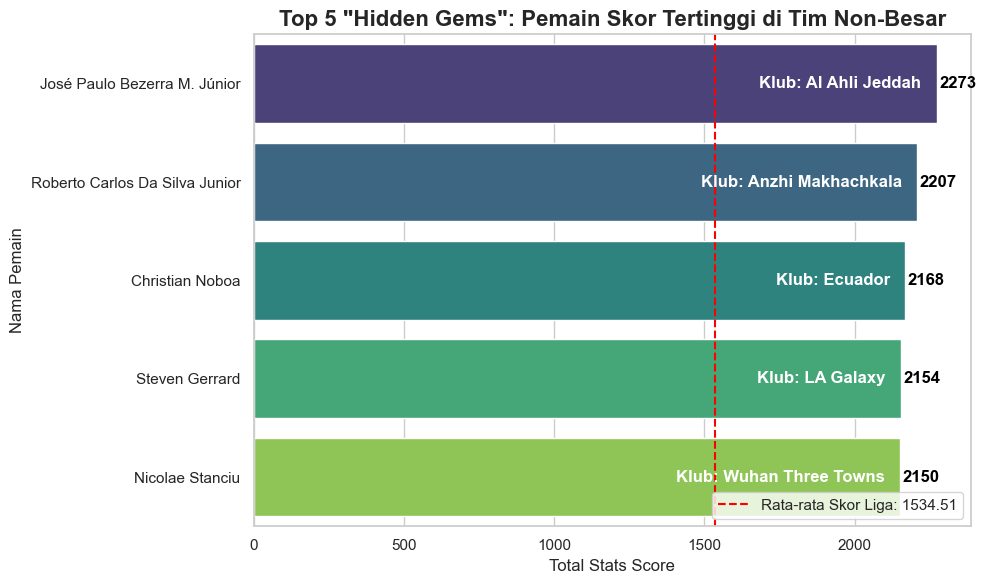

In [35]:
# 1. Atur gaya visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Buat Horizontal Bar Chart
# Kita gunakan Total_Stats Score sebagai sumbu X dan Name sebagai sumbu Y
ax = sns.barplot(
    data=sortPlayer, 
    x='Total_Stats Score', 
    y='Name', 
    palette='viridis'
)

# 3. Tambahkan label nama klub di dalam batang
for i, (value, team) in enumerate(zip(sortPlayer['Total_Stats Score'], sortPlayer['Team'])):
    ax.text(value - 50, i, f"Klub: {team}", color='white', va='center', fontweight='bold', ha='right')

# 4. Tambahkan garis rata-rata liga sebagai referensi
plt.axvline(mean_score, color='red', linestyle='--', label=f'Rata-rata Skor Liga: {mean_score:.2f}')

# 5. Labeling
plt.title('Top 5 "Hidden Gems": Pemain Skor Tertinggi di Tim Non-Besar', fontsize=16, fontweight='bold')
plt.xlabel('Total Stats Score', fontsize=12)
plt.ylabel('Nama Pemain', fontsize=12)
plt.legend(loc='lower right')

# Tambahkan nilai skor di ujung batang
for i, v in enumerate(sortPlayer['Total_Stats Score']):
    ax.text(v + 10, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# soal nomor 2
data_position = df.groupby('Position')[['Total_Stats Score']].mean()
mean_MF = data_position.loc[['CM','CAM','CDM','LM','RM']].mean()
mean_GK = data_position.loc['GK']
perbandiangan = (mean_GK / mean_MF).round(2)

print(f"Perbandingan Total Stats Score Pada posisi Goalkeeper dan Midfielder sebesar: {perbandiangan.iloc[0]} ")

Perbandingan Total Stats Score Pada posisi Goalkeeper dan Midfielder sebesar: 0.59 


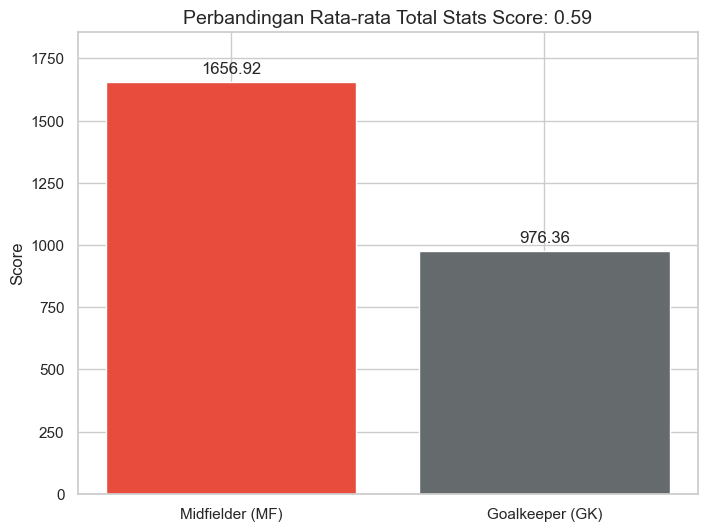

In [85]:
labels = ['Midfielder (MF)', 'Goalkeeper (GK)']
values = [mean_MF.iloc[0], mean_GK.iloc[0]]
colors = ['#e74c3c' if (x == max(values)) else "#656a6d" for x in values]

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values, color=colors)
plt.title(f'Perbandingan Rata-rata Total Stats Score: {perbandiangan.iloc[0]}', fontsize=14)
plt.ylabel('Score')
plt.ylim(0, max(values) + 200) # Memberi ruang di atas batang

# Menambahkan label angka di atas batang
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20, round(yval, 2), ha='center', va='bottom')

plt.show()